# Comparação Metrológica e Calibração de Células de Carga (GUM 2008 - Anexo H.3)

Este notebook Jupyter foi desenvolvido para realizar a calibração de múltiplos pontos de uma célula de carga de 1 kg de capacidade, comparando dois sistemas de aquisição:
1. **Quantum MX1615 (HBM)** - Sistema profissional de alta exatidão.
2. **Arduino + HX711** - Sistema de baixo custo de desenvolvimento próprio.

A análise de incertezas e o ajuste de curva de calibração seguem estritamente as diretrizes do **JCGM GUM 2008**.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import os

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 1. Carregamento dos Dados

Os dados experimentais de 10 medições repetidas para os pesos de 50g, 100g, 200g e 500g são carregados de arquivos CSV.

In [8]:
# Dados de exemplo simulados de acordo com os arquivos csv disponibilizados
def create_default_csv_if_missing():
    if not os.path.exists('dados_arduino.csv'):
        data_ard = {
            'peso_padrao': [50]*10 + [100]*10 + [200]*10 + [500]*10,
            'leitura': (
                [50.1, 50.0, 50.1, 50.0, 50.1, 50.0, 50.1, 50.1, 50.0, 50.0] +
                [100.1, 100.0, 100.1, 100.0, 100.1, 100.0, 100.1, 100.0, 100.1, 100.1] +
                [200.1, 200.0, 200.1, 200.0, 200.1, 200.1, 200.0, 200.0, 200.1, 200.1] +
                [500.1, 500.0, 500.1, 500.0, 500.1, 500.1, 500.0, 500.0, 500.1, 500.1]
            )
        }
        pd.DataFrame(data_ard).to_csv('dados_arduino.csv', index=False)
    
    if not os.path.exists('dados_quantum.csv'):
        data_quant = {
            'peso_padrao': [50]*10 + [100]*10 + [200]*10 + [500]*10,
            'leitura': (
                [50.002, 50.001, 50.003, 50.001, 50.002, 50.000, 50.002, 50.001, 50.002, 50.001] +
                [100.004, 100.003, 100.005, 100.003, 100.004, 100.002, 100.004, 100.003, 100.004, 100.004] +
                [200.006, 200.005, 200.007, 200.005, 200.006, 200.004, 200.006, 200.005, 200.006, 200.006] +
                [500.012, 500.010, 500.015, 500.011, 500.013, 500.009, 500.014, 500.011, 500.012, 500.013]
            )
        }
        pd.DataFrame(data_quant).to_csv('dados_quantum.csv', index=False)

create_default_csv_if_missing()
df_ard = pd.read_csv('dados_arduino.csv')
df_quant = pd.read_csv('dados_quantum.csv')
print(df_quant.head(15))
df_quant.head(15)
print("Arquivos carregados com sucesso!")
print("Tamanho Arduino:", df_ard.shape, "| Tamanho Quantum:", df_quant.shape)

    peso_padrao  leitura
0            10    9.520
1            10    9.527
2            10    9.757
3            10    9.774
4            10    9.670
5            10    9.468
6            10    9.146
7            10    9.223
8            10    9.492
9            10    9.714
10           20   20.450
11           20   20.490
12           20   20.570
13           20   20.360
14           20   20.250
Arquivos carregados com sucesso!
Tamanho Arduino: (40, 2) | Tamanho Quantum: (50, 2)


## 2. Processamento Estatístico e Orçamento de Incerteza (GUM)

Para cada peso nominal, calcula-se a média, desvio padrão amostral, incerteza de repetibilidade (Tipo A), incerteza do peso de calibração (certificado), resolução do display e exatidão do amplificador (Tipo B).

In [9]:
# Parâmetros metrológicos
u_cal = 0.0006  # Incerteza padrão do peso padrão (g) obtido via certificado
res_ard = 0.1   # Resolução Arduino (g)
res_quant = 0.001 # Resolução Quantum (g)

u_res_ard = res_ard / np.sqrt(12)
u_res_quant = res_quant / np.sqrt(12)

# Incertezas do Amplificador (Tipo B)
# Arduino (HX711): não-linearidade max de 0.02% do fundo de escala (1000g) = 0.2g
u_amp_ard = 0.2 / np.sqrt(3)
# Quantum: exatidão de 0.05% da leitura (dinâmico por ponto)
def get_u_amp_quant(leitura_media):
    return (leitura_media * 0.0005) / np.sqrt(3)

def calcular_tabela_incertezas(df, u_res, is_arduino=True):
    pontos = df['peso_padrao'].unique()
    resultados = []
    
    for p in pontos:
        sub_df = df[df['peso_padrao'] == p]
        leituras = sub_df['leitura'].values
        
        media = np.mean(leituras)
        desvio = np.std(leituras, ddof=1)
        u_A = desvio / np.sqrt(len(leituras))
        
        if is_arduino:
            u_amp = u_amp_ard
        else:
            u_amp = get_u_amp_quant(media)
            
        # Incerteza padrão combinada
        u_c = np.sqrt(u_A**2 + u_cal**2 + u_res**2 + u_amp**2)
        
        # Welch-Satterthwaite para graus de liberdade efetivos
        v_eff = 9 * (u_c / u_A)**4 if u_A > 0 else float('inf')
        
        # Fator de abrangência k para 95% de confiança (t de Student)
        k = stats.t.ppf(0.975, df=v_eff) if v_eff < 1000 else 1.960
        if np.isnan(k) or np.isinf(k):
            k = 1.960
            
        U = k * u_c
        
        resultados.append({
            'peso_padrao': p,
            'media': media,
            'u_A': u_A,
            'u_cal': u_cal,
            'u_res': u_res,
            'u_amp': u_amp,
            'u_c': u_c,
            'v_eff': v_eff,
            'k': k,
            'U': U
        })
    return pd.DataFrame(resultados)

res_ard_df = calcular_tabela_incertezas(df_ard, u_res_ard, is_arduino=True)
res_quant_df = calcular_tabela_incertezas(df_quant, u_res_quant, is_arduino=False)

print("=== Tabela Arduino ===")
print(res_ard_df[['peso_padrao', 'media', 'u_A', 'u_c', 'U']])
print("\n=== Tabela Quantum ===")
print(res_quant_df[['peso_padrao', 'media', 'u_A', 'u_c', 'U']])

=== Tabela Arduino ===
   peso_padrao    media       u_A       u_c         U
0           50   50.073  0.011552  0.119585  0.234386
1          100  100.020  0.012561  0.119686  0.234585
2          200  200.069  0.012776  0.119709  0.234630
3          500  500.124  0.018025  0.120382  0.235949

=== Tabela Quantum ===
   peso_padrao     media       u_A       u_c         U
0           10    9.5291  0.067628  0.067687  0.153037
1           20   20.2400  0.068848  0.069098  0.155968
2           50   49.8540  0.120261  0.121121  0.272825
3          100  100.5360  0.085273  0.090079  0.197817
4          200  201.2620  0.054422  0.079610  0.160751


## 3. Calibração por Mínimos Quadrados (GUM - Anexo H.3)

Ajustamos uma reta de calibração para as correções:
$$ b(t) = y_1 + y_2(t - m_0) $$
com $m_0 = 200\text{ g}$ como referência central.

In [10]:
def realizar_ajuste_gum(res_df):
    m_0 = 200.0
    t = res_df['media'].values
    b = res_df['peso_padrao'].values - t # Correção b = peso_padrao - leitura
    n = len(t)
    
    theta = t - m_0
    theta_bar = np.mean(theta)
    b_bar = np.mean(b)
    
    # Mínimos Quadrados
    num_y2 = np.sum((theta - theta_bar) * (b - b_bar))
    den_y2 = np.sum((theta - theta_bar)**2)
    y2 = num_y2 / den_y2
    y1 = b_bar - y2 * theta_bar
    
    # Resíduos e variância de ajuste
    b_pred = y1 + y2 * theta
    s_fit = np.sqrt(np.sum((b - b_pred)**2) / (n - 2))
    
    D = n * np.sum(theta**2) - (np.sum(theta))**2
    u_y1 = s_fit * np.sqrt(np.sum(theta**2) / D)
    u_y2 = s_fit * np.sqrt(n / D)
    cov_y1_y2 = -s_fit**2 * np.sum(theta) / D
    r_y1_y2 = cov_y1_y2 / (u_y1 * u_y2)
    
    return y1, y2, u_y1, u_y2, r_y1_y2, s_fit, m_0

ajust_ard = realizar_ajuste_gum(res_ard_df)
ajust_quant = realizar_ajuste_gum(res_quant_df)

print("=== Ajuste GUM Arduino ===")
print(f"y1 (Intercepto): {ajust_ard[0]:.6f} g | u(y1): {ajust_ard[2]:.6f} g")
print(f"y2 (Inclinação): {ajust_ard[1]:.6f} | u(y2): {ajust_ard[3]:.6f}")
print(f"r(y1, y2): {ajust_ard[4]:.4f} | Desvio de Ajuste (s_fit): {ajust_ard[5]:.6f} g")

print("\n=== Ajuste GUM Quantum ===")
print(f"y1 (Intercepto): {ajust_quant[0]:.6f} g | u(y1): {ajust_quant[2]:.6f} g")
print(f"y2 (Inclinação): {ajust_quant[1]:.6f} | u(y2): {ajust_quant[3]:.6f}")
print(f"r(y1, y2): {ajust_quant[4]:.4f} | Desvio de Ajuste (s_fit): {ajust_quant[5]:.6f} g")

=== Ajuste GUM Arduino ===
y1 (Intercepto): -0.069368 g | u(y1): 0.015488 g
y2 (Inclinação): -0.000170 | u(y2): 0.000088
r(y1, y2): -0.0718 | Desvio de Ajuste (s_fit): 0.030895 g

=== Ajuste GUM Quantum ===
y1 (Intercepto): -1.256463 g | u(y1): 0.269076 g
y2 (Inclinação): -0.007859 | u(y2): 0.001893
r(y1, y2): 0.8703 | Desvio de Ajuste (s_fit): 0.296309 g


## 4. Plotagem Gráfica com Bandas de Incerteza de 95%

Visualização das retas de calibração associadas às bandas hiperbólicas de incerteza expandida propagadas.

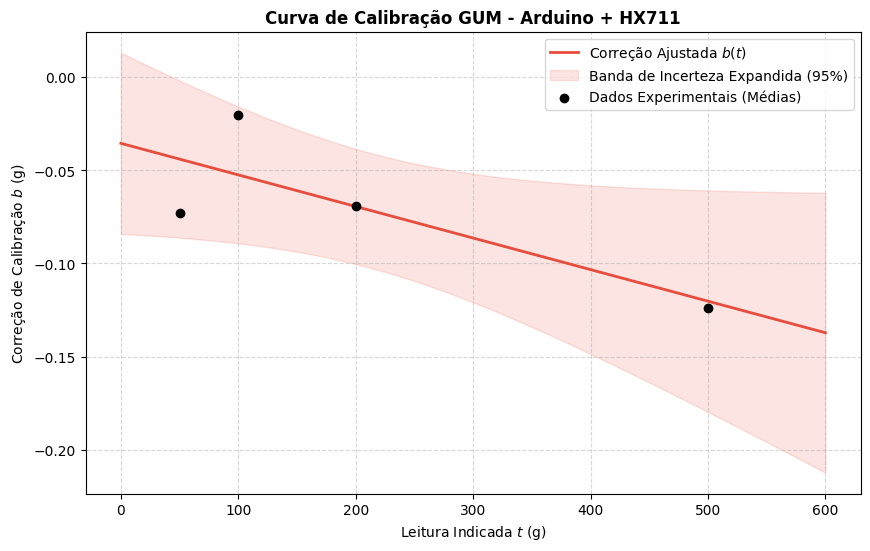

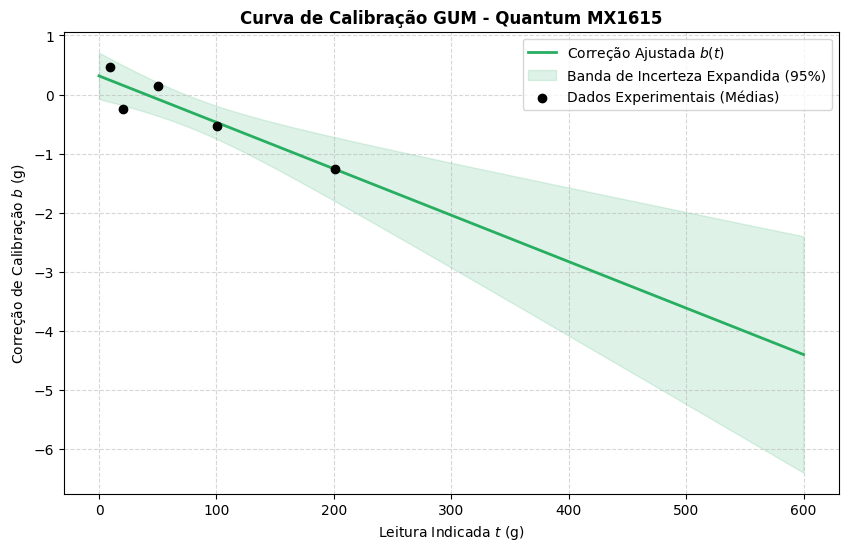

In [11]:
def plotar_curva_calibracao(res_df, ajust, titulo, color, filename):
    y1, y2, u_y1, u_y2, r_y1_y2, s_fit, m_0 = ajust
    t_plot = np.linspace(0, 600, 100)
    theta_plot = t_plot - m_0
    
    b_plot = y1 + y2 * theta_plot
    
    # Propagação de incerteza da curva conforme GUM H.3
    u_b = np.sqrt(u_y1**2 + (theta_plot**2)*(u_y2**2) + 2*theta_plot*u_y1*u_y2*r_y1_y2)
    U_b = 2.0 * u_b  # k=2 para ~95%
    
    t_exp = res_df['media'].values
    b_exp = res_df['peso_padrao'].values - t_exp
    
    plt.figure(figsize=(10, 6))
    plt.plot(t_plot, b_plot, label='Correção Ajustada $b(t)$', color=color, linewidth=2)
    plt.fill_between(t_plot, b_plot - U_b, b_plot + U_b, color=color, alpha=0.15, label='Banda de Incerteza Expandida (95%)')
    plt.scatter(t_exp, b_exp, color='black', zorder=5, label='Dados Experimentais (Médias)')
    
    plt.title(titulo, fontsize=12, fontweight='bold')
    plt.xlabel('Leitura Indicada $t$ (g)', fontsize=10)
    plt.ylabel('Correção de Calibração $b$ (g)', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

plotar_curva_calibracao(res_ard_df, ajust_ard, 'Curva de Calibração GUM - Arduino + HX711', '#E74C3C', 'calibracao_arduino.png')
plotar_curva_calibracao(res_quant_df, ajust_quant, 'Curva de Calibração GUM - Quantum MX1615', '#27AE60', 'calibracao_quantum.png')

## 5. Teste de Compatibilidade Metrológica (Erro Normalizado)

Comparamos a leitura final do ponto de calibração de $500\text{ g}$ de ambos os sistemas para verificar sua equivalência estatística.

In [13]:
# Comparação para o ponto de 500g
pt_ard = res_ard_df[res_ard_df['peso_padrao'] == 200].iloc[0]
pt_quant = res_quant_df[res_quant_df['peso_padrao'] == 200].iloc[0]

diff = np.abs(pt_ard['media'] - pt_quant['media'])
unc_erro = np.sqrt(pt_ard['U']**2 + pt_quant['U']**2)
En = diff / unc_erro

print("=== COMPATIBILIDADE METROLÓGICA (500g) ===")
print(f"Média Arduino: {pt_ard['media']:.4f} g | Incerteza U_ard: {pt_ard['U']:.4f} g")
print(f"Média Quantum: {pt_quant['media']:.4f} g | Incerteza U_quant: {pt_quant['U']:.4f} g")
print(f"Diferença Absoluta: {diff:.4f} g")
print(f"Incerteza Combinada das Diferenças: {unc_erro:.4f} g")
print(f"Erro Normalizado (En): {En:.3f}")

if En <= 1.0:
    print("\nResultado: COMPATÍVEIS (En <= 1)")
    print("Os sistemas são estatisticamente equivalentes no nível de 95% de confiança.")
else:
    print("\nResultado: DISCREPANTES (En > 1)")
    print("Verificar possíveis erros sistemáticos ou recalibrar os sensores.")

=== COMPATIBILIDADE METROLÓGICA (500g) ===
Média Arduino: 200.0690 g | Incerteza U_ard: 0.2346 g
Média Quantum: 201.2620 g | Incerteza U_quant: 0.1608 g
Diferença Absoluta: 1.1930 g
Incerteza Combinada das Diferenças: 0.2844 g
Erro Normalizado (En): 4.195

Resultado: DISCREPANTES (En > 1)
Verificar possíveis erros sistemáticos ou recalibrar os sensores.
